# Comparación de algoritmos, distancias y representaciones para clustering

## Objetivo

En este notebook vamos a estudiar una pregunta central en ciencia de datos:

> ¿Qué determina la calidad de un clustering?

Analizaremos tres factores:

- El algoritmo de clustering utilizado
- La medida de distancia o similitud
- La representación de los datos

Compararemos distintos métodos sobre datasets sintéticos con estructuras diferentes y utilizaremos métricas de validación interna y externa para evaluar los resultados.

---

## Algoritmos

- K-Means
- K-Medoids
- DBSCAN
- Clustering Jerárquico
- Fuzzy C-Means

---

## Métricas de validación

### Externas

- Adjusted Rand Index (ARI)
- Distancia Normalizada de van Dongen

### Internas

- Silhouette Score
- Silhouette Plot

---

## Pregunta guía

¿Es más importante elegir el algoritmo correcto, la distancia correcta o una buena representación de los datos?

## Observación
Por una cuestión de brevedad, en esta práctica no validaremos cada parámetro de cada algoritmo sino que los asumiremos dados, ya que el objetivo es ver cómo la elección de distancias y representaciones afectan resultados, incluso con parámetros óptimos

## Instalamos y cargamos librerías





In [ ]:
!pip install numpy==1.26.4 # scikit-learn-extra no es compatible con numpy posteriores
!pip install scikit-learn-extra
!pip install scikit-fuzzy
!pip install umap-learn


import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import make_blobs
from sklearn.datasets import make_moons
from sklearn.datasets import make_circles

from sklearn.cluster import (
    KMeans,
    DBSCAN,
    AgglomerativeClustering
)

from sklearn_extra.cluster import KMedoids

import skfuzzy as fuzz

from sklearn.metrics import (
    adjusted_rand_score,
    silhouette_score,
    silhouette_samples
)

from sklearn.metrics import pairwise_distances
from sklearn.metrics.cluster import contingency_matrix
from sklearn.preprocessing import StandardScaler

sns.set_style("whitegrid")

## Definimos funciones auxiliares

In [ ]:
# Índice normalizado de Van Dongen
def normalized_van_dongen(labels_true, labels_pred):

    labels_true = np.asarray(labels_true)
    labels_pred = np.asarray(labels_pred)
    n = len(labels_true)

    # Matriz de contingencia (n_ij)
    C = contingency_matrix(labels_true, labels_pred)

    # n_i. (suma por filas) y n_.j (suma por columnas)
    row_sums = C.sum(axis=1)
    col_sums = C.sum(axis=0)

    # Numerador: 2n - sum(max_j n_ij) - sum(max_i n_ij)
    num = 2 * n - np.sum(np.max(C, axis=1)) - np.sum(np.max(C, axis=0))

    # Denominador: 2n - max(n_i.) - max(n_.j)
    den = 2 * n - np.max(row_sums) - np.max(col_sums)

    return num / den

In [ ]:
# Gráfico de silhouette
def plot_silhouette(X, labels):

    if len(np.unique(labels)) < 2:
        print("No hay suficientes clusters.")
        return

    silhouette_avg = silhouette_score(X, labels)

    sample_values = silhouette_samples(X, labels)

    fig, ax = plt.subplots(figsize=(7,5))

    y_lower = 10

    for cluster in np.unique(labels):

        vals = sample_values[labels == cluster]
        vals.sort()

        size_cluster = len(vals)

        y_upper = y_lower + size_cluster

        ax.fill_betweenx(
            np.arange(y_lower, y_upper),
            0,
            vals,
            alpha=0.7
        )

        ax.text(
            -0.05,
            y_lower + 0.5*size_cluster,
            str(cluster)
        )

        y_lower = y_upper + 10

    ax.axvline(
        silhouette_avg,
        color='red',
        linestyle='--'
    )

    ax.set_xlabel("Silhouette")
    ax.set_ylabel("Cluster")

    ax.set_title(
        f"Silhouette Plot\nPromedio={silhouette_avg:.3f}"
    )

    plt.show()

In [ ]:
# Visualización de resultados
def plot_clustering(X, labels, title):

    plt.figure(figsize=(6,5))

    plt.scatter(
        X[:,0],
        X[:,1],
        c=labels,
        cmap='tab10',
        s=15
    )

    plt.title(title)

    plt.show()

## Implementación de algoritmos de clustering

In [ ]:
# K-means
def run_kmeans(X, k):

    model = KMeans(
        n_clusters=k,
        random_state=0,
        n_init=20,
    )

    labels = model.fit_predict(X)

    return labels

In [ ]:
# K-medoids
def run_kmedoids(X, k, metric='euclidean'):

    model = KMedoids(
        n_clusters=k,
        metric=metric,
        random_state=0,
        init='k-medoids++'
    )

    labels = model.fit_predict(X)

    return labels

In [ ]:
# Jerárquico
def run_hierarchical(X, k, linkage='ward'):

    model = AgglomerativeClustering(
        n_clusters=k,
        linkage=linkage
    )

    labels = model.fit_predict(X)

    return labels

In [ ]:
# DBSCAN
def run_dbscan(
    X,
    eps=0.3,
    min_samples=5
):

    model = DBSCAN(
        eps=eps,
        min_samples=min_samples
    )

    labels = model.fit_predict(X)

    return labels

Para facilitar la comparación entre métodos vamos a hacer un C-means donde forzamos una partición exlusiva

In [ ]:
# C-means (forzado a exlcusivo)
def run_cmeans(X, k):

    cntr, u, _, _, _, _, _ = fuzz.cluster.cmeans(
        X.T,
        c=k,
        m=2,
        error=0.005,
        maxiter=1000
    )

    # AQUI NOS QUEDAMOS CON LA PROBABILIDAD DE PERTENCIA A CLUSTER MAS ALTA
    labels = np.argmax(u, axis=0)

    return labels

## Función general de benchmarking

In [ ]:
def benchmark_clustering(
    X,
    y_true,
    k
):

    results = []

    methods = {
        "KMeans":
            run_kmeans(X,k),

        "KMedoids":
            run_kmedoids(X,k),

        "Hierarchical":
            run_hierarchical(X,k),

        "CMeans":
            run_cmeans(X,k)
    }

    for name, labels in methods.items():

        ari = adjusted_rand_score(
            y_true,
            labels
        )

        vd = normalized_van_dongen(
            y_true,
            labels
        )

        sil = silhouette_score(
            X,
            labels
        )

        results.append([
            name,
            ari,
            vd,
            sil
        ])

    results = pd.DataFrame(
        results,
        columns=[
            "Método",
            "ARI",
            "vanDongen",
            "Silhouette"
        ]
    )

    return results.sort_values(
        "ARI",
        ascending=False
    )

#Dataset 1: clusters esféricos

In [ ]:
# Generamos 4 clusters esféricos
X,y = make_blobs(
    n_samples=1000,
    n_features=2,
    centers=4,
    cluster_std=1,
    random_state=0
)

X = StandardScaler().fit_transform(X)

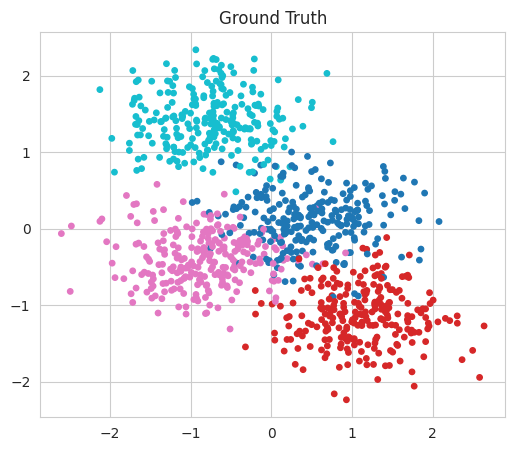

In [ ]:
# Visualizamos con las etiquetas
plot_clustering(
    X,
    y,
    "Ground Truth"
)

### Son clusters globulares, probemos primero con k-means

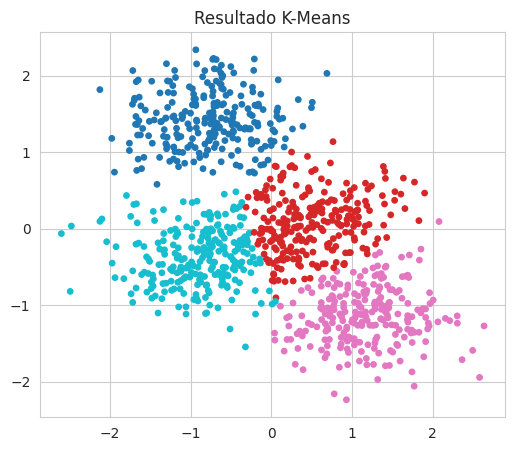

In [ ]:
labels=run_kmeans(X,4)

plot_clustering(
    X,
    labels,
    "Resultado K-Means"
)

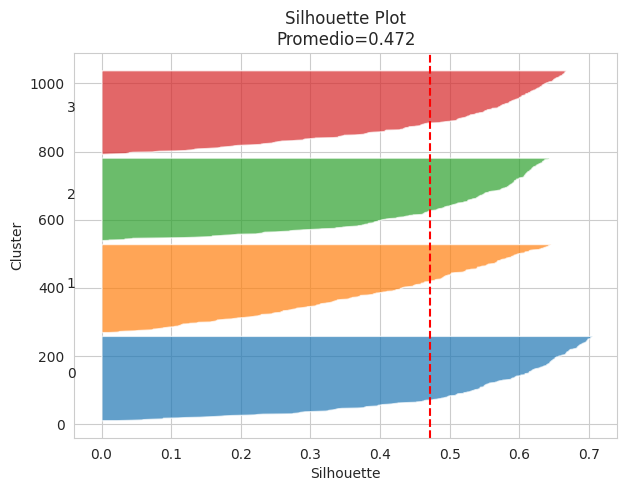

In [ ]:
plot_silhouette(X, labels)

### Validación de diferentes métodos


In [ ]:
# Validamos los resultados de los diferentes algoritmos
results = benchmark_clustering(
    X,
    y,
    k=4
)

results

,Método,ARI,vanDongen,Silhouette
0,KMeans,0.810139,0.103356,0.471844
3,CMeans,0.810052,0.103356,0.471688
2,Hierarchical,0.754084,0.141796,0.442046
1,KMedoids,0.493791,0.375273,0.399901


### Discusión

1. ¿Qué algoritmo obtuvo mejor ARI?

2. ¿Hay diferencias relevantes entre K-Means y K-Medoids?

3. ¿Vale la pena utilizar algoritmos más complejos en este dataset?

4. ¿Coinciden ARI y Silhouette?

# Dataset 2: Dos "Lunas"

In [ ]:
# Generamos dataset
X,y = make_moons(
    n_samples=1000,
    noise=0.05,
    random_state=0
)

X = StandardScaler().fit_transform(X)

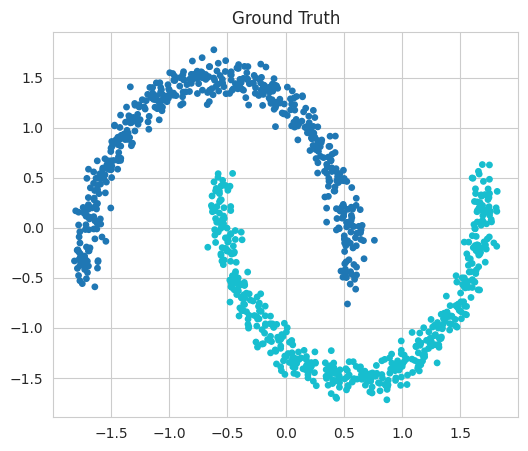

In [ ]:
# Visualizamos etiquetas
plot_clustering(
    X,
    y,
    "Ground Truth"
)

### Comparamos k-means con DBSCAN

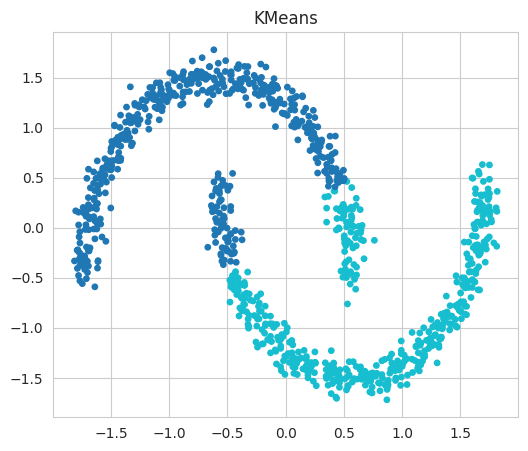

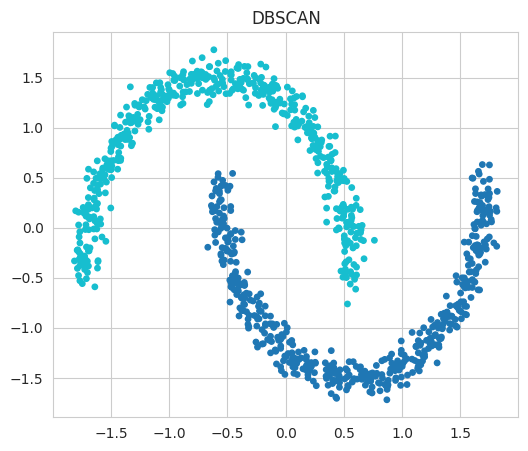

In [ ]:
labels = run_kmeans(X,2)

plot_clustering(
    X,
    labels,
    "KMeans"
)

labels = run_dbscan(X,eps=0.3, min_samples=5) # probar con otros parámetros!

plot_clustering(
    X,
    labels,
    "DBSCAN"
)

### Discusión

¿Por qué K-Means fracasa en este dataset?

¿Qué propiedad geométrica de los clusters viola las hipótesis implícitas de K-Means?

# Distancias para datos continuos

Hasta ahora hemos utilizado implícitamente la distancia Euclidiana.

Sin embargo, muchas técnicas de clustering pueden utilizar otras medidas de distancia.

En esta sección compararemos:

- **Euclidiana**
- **Manhattan**
- **Coseno**


y analizaremos cómo afectan los resultados del clustering.

Los algoritmos de clustering que usaremos son **k-medoids** y **jerárquico**, que permiten utilizar distancias precomputadas

## Función auxiliar

In [ ]:
from sklearn.metrics import pairwise_distances

def evaluate_distance_metric(
    X,
    y_true,
    metric,
    k=4
):

    results = []

    # K-Medoids

    labels = run_kmedoids(
        X,
        k,
        metric=metric
    )

    ari = adjusted_rand_score(y_true, labels)

    vd = normalized_van_dongen(
        y_true,
        labels
    )

    sil = silhouette_score(
        X,
        labels
    )

    results.append([
        "KMedoids",
        metric,
        ari,
        vd,
        sil
    ])

    # Jerárquico

    D = pairwise_distances(
        X,
        metric=metric
    )

    labels = AgglomerativeClustering(
        n_clusters=k,
        metric='precomputed',
        linkage='average'
    ).fit_predict(D)

    ari = adjusted_rand_score(y_true, labels)

    vd = normalized_van_dongen(
        y_true,
        labels
    )

    sil = silhouette_score(
        X,
        labels
    )

    results.append([
        "Hierarchical",
        metric,
        ari,
        vd,
        sil
    ])

    return results

## Comparación de distancias

In [ ]:
# Generamos 4 clusters esféricos
X,y = make_blobs(
    n_samples=1000,
    centers=4,
    cluster_std=1,
    random_state=0
)

X = StandardScaler().fit_transform(X)

In [ ]:
metrics = [
    'euclidean',
    'manhattan',
    'cosine'
]

all_results = []

for metric in metrics:

    all_results.extend(
        evaluate_distance_metric(
            X,
            y,
            metric,
            k=4
        )
    )

results = pd.DataFrame(
    all_results,
    columns=[
        'Método',
        'Distancia',
        'ARI',
        'vanDongen',
        'Silhouette'
    ]
)

results

,Método,Distancia,ARI,vanDongen,Silhouette
0,KMedoids,euclidean,0.493791,0.375273,0.399901
1,Hierarchical,euclidean,0.767597,0.133062,0.447042
2,KMedoids,manhattan,0.499326,0.363438,0.391438
3,Hierarchical,manhattan,0.588697,0.273829,0.363738
4,KMedoids,cosine,0.686311,0.190542,0.414272
5,Hierarchical,cosine,0.641461,0.225053,0.396572


## Heatmap de resultados

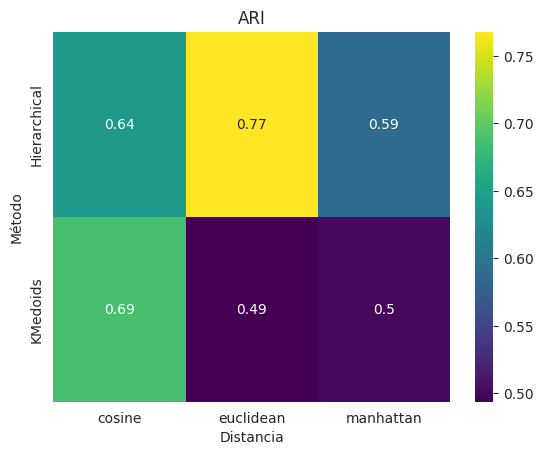

In [ ]:
pivot = results.pivot_table(
    index='Método',
    columns='Distancia',
    values='ARI'
)

sns.heatmap(
    pivot,
    annot=True,
    cmap='viridis'
)

plt.title("ARI")
plt.show()

### Discusión

1. ¿Las tres distancias producen resultados similares?

2. ¿Hay alguna distancia que sistemáticamente funcione mejor?

3. ¿La elección de la distancia es tan importante como la elección del algoritmo?

# Datos binarios

Ahora trabajaremos con variables binarias.

Ejemplos reales:

- Presencia o ausencia de especies
- Compra o no compra de productos
- Presencia o ausencia de síntomas
- Activación o no activación de genes

Para este tipo de datos suelen utilizarse medidas de similitud específicas.

Usaremos

- **Distancia de Jaccard**
- **Distancia basada en simple matching coefficient**

Algoritmo de clustering que usaremos: clustering jerárquico (¿Qué otro algoritmo podríamos usar?)

## Generación del dataset
Generamos tres grupos de datos con probabilidades distintas de 1s (0.8, 0.5 y 0.2), donde cada grupo consiste en 300 observaciones en un espacio de 50 atributos binarios.


In [ ]:
np.random.seed(0)

n = 300

cluster1 = np.random.binomial(
    1,
    0.8,
    (n,50)
)

cluster2 = np.random.binomial(
    1,
    0.5,
    (n,50)
)

cluster3 = np.random.binomial(
    1,
    0.2,
    (n,50)
)

X = np.vstack([
    cluster1,
    cluster2,
    cluster3
])

y = np.repeat(
    [0,1,2],
    n
)

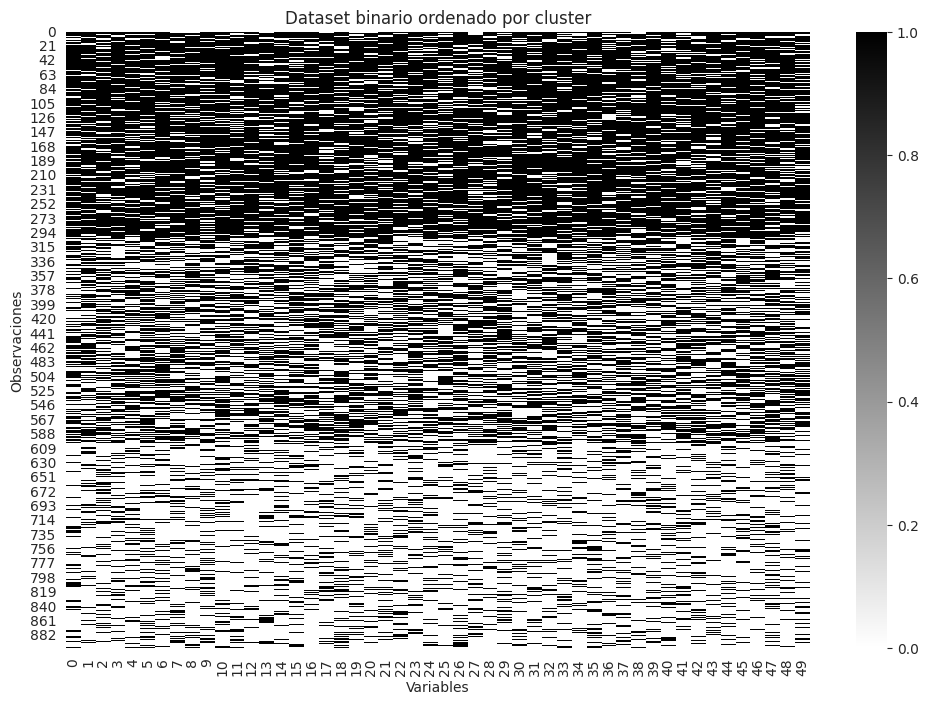

In [ ]:
# Visualizamos el dataset
idx = np.argsort(y)

X_sorted = X[idx]
y_sorted = y[idx]

plt.figure(figsize=(12,8))

sns.heatmap(
    X_sorted,
    cmap="binary",
    cbar=True
)

plt.xlabel("Variables")
plt.ylabel("Observaciones")

plt.title("Dataset binario ordenado por cluster")

plt.show()

### Recordatorio de distancias binarias

Si definimos

$a$: $x$ = 1 & $y$ = 1

$b$: $x$ = 1 & $y$ = 0

$c$: $x$ = 0 & $y$ = 1

$d$: $x$ = 0 & $y$ = 0

donde $x$ e $y$ son los valores de un atributo de dos observaciones

<br />



**Jaccard coefficient**:

$Jaccard$ = $\frac{a}{a+b+c+d}$

<br />
Distancia basada en Jaccard:

$distJaccard=1−Jaccard$

<br /> <br />


**Simple matching coefficient (SMC)**:

$SMC$ = $\frac{a+b}{a+b+c+d}$

<br />

Distancia basada en SMB:

$distSMC=1−SMC$



In [ ]:
# Jaccard ya está implementada
D_jaccard = pairwise_distances(
    X,
    metric='jaccard'
)

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/pairwise.py:2466: DataConversionWarning: Data was converted to boolean for metric jaccard
  warnings.warn(msg, DataConversionWarning)


In [ ]:
# Implementación de distancia de SMC
def smc_distance(x,y):

    matches = np.sum(x==y)

    return 1 - matches/len(x)

D_smc = pairwise_distances(
    X,
    metric=smc_distance
)

In [ ]:
for name,D in [
    ("Jaccard",D_jaccard),
    ("distSMC",D_smc)
]:

    labels = AgglomerativeClustering(
        n_clusters=3,
        metric='precomputed',
        linkage='average'
    ).fit_predict(D)

    print(name)

    print(
        "ARI:",
        adjusted_rand_score(
            y,
            labels
        )
    )

Jaccard
ARI: 6.959944965726601e-05
distSMC
ARI: 0.45076849371066724


### Discusión

1. ¿Qué ocurre cuando predominan los ceros?

2. ¿Cuál de las dos medidas de distancia ignora las coincidencias de ausencia?

3. ¿Qué distancia parece más apropiada para datos de presencia-ausencia?

# Datos categóricos multiestado


Ahora consideraremos variables categóricas nominales que pueden tomar múltiples estados posibles.

Ejemplos:

- Color favorito
- Provincia de residencia
- Marca de teléfono celular
- Tipo de vehículo

Estas variables no poseen un orden natural.

Por ejemplo, si codificamos:

- Rojo = 0
- Verde = 1
- Azul = 2

no tiene sentido afirmar que "Azul está más lejos de Rojo que de Verde".

Por esta razón, las variables categóricas suelen transformarse mediante **One-Hot Encoding**.

---

## One-Hot Encoding

Supongamos una variable "Color":

| Color |
|---------|
| Rojo |
| Verde |
| Azul |

Luego del One-Hot Encoding obtenemos:

| Rojo | Verde | Azul |
|---------|---------|---------|
| 1 | 0 | 0 |
| 0 | 1 | 0 |
| 0 | 0 | 1 |

Cada categoría queda representada por una variable binaria.

---

## Objetivo

Analizar cómo realizar clustering sobre variables categóricas representadas mediante One-Hot Encoding.

Utilizaremos una medida de similitud basada en coincidencias entre categorías.

## Dataset sintético de encuesta

En esta sección trabajaremos con un conjunto de datos que simula respuestas a una encuesta.

Cada observación representa un individuo y cada variable corresponde a una pregunta categórica.

Ejemplos de preguntas:

- Medio de transporte habitual
- Bebida preferida
- Género musical favorito
- Plataforma de streaming utilizada
- Deporte preferido

Los datos fueron generados a partir de tres grupos latentes con preferencias diferentes.

Sin embargo, ningún grupo posee categorías exclusivas: todas las respuestas pueden aparecer en todos los grupos, aunque con probabilidades distintas.

Esta situación es mucho más cercana a los problemas reales de segmentación de clientes o análisis de encuestas.

En problemas reales de clustering, existen varias formas de representar este tipo de datos.

En esta sección compararemos dos enfoques:

## Enfoque A

Variables categóricas originales

↓

Coeficiente de coincidencia

↓

Clustering

## Enfoque B

Variables categóricas

↓

One-Hot Encoding

↓

Distancia de Jaccard

↓

Clustering

El objetivo es analizar si distintas representaciones producen resultados similares o diferentes.

In [ ]:
# Definición de parámetros de cada cluster sintético
# Generaremos 3 clusters de 300 observaciones para las 5 posibles preguntas
np.random.seed(0)

n = 300

variables = {

    "transporte":
        ["Auto","Colectivo","Subte","Bicicleta"],

    "bebida":
        ["Cafe","Te","Gaseosa","Agua"],

    "musica":
        ["Rock","Pop","Clasica","Electronica"],

    "streaming":
        ["Netflix","Disney","Prime","HBO"],

    "deporte":
        ["Futbol","Tenis","Running","Ninguno"]

}

# Cluster 1 ("perfil urbano jóven")
cluster1_probs = {

"transporte":[0.10,0.20,0.40,0.30],

"bebida":[0.45,0.15,0.10,0.30],

"musica":[0.20,0.15,0.05,0.60],

"streaming":[0.50,0.10,0.15,0.25],

"deporte":[0.15,0.10,0.50,0.25]
}

# Cluster 2 ("perfil familiar")

cluster2_probs = {

"transporte":[0.60,0.25,0.05,0.10],

"bebida":[0.10,0.20,0.40,0.30],

"musica":[0.40,0.40,0.10,0.10],

"streaming":[0.20,0.50,0.20,0.10],

"deporte":[0.50,0.15,0.10,0.25]
}

# Cluster 3 ("perfil tradicional")

cluster3_probs = {

"transporte":[0.50,0.20,0.05,0.25],

"bebida":[0.15,0.50,0.05,0.30],

"musica":[0.15,0.10,0.60,0.15],

"streaming":[0.15,0.20,0.15,0.50],

"deporte":[0.10,0.30,0.10,0.50]
}




In [ ]:
# Función generadora
def generate_cluster(n_samples, probs):

    data = {}

    for var, categories in variables.items():

        data[var] = np.random.choice(
            categories,
            size=n_samples,
            p=probs[var]
        )

    return pd.DataFrame(data)

In [ ]:
# Construcción del dataset
df1 = generate_cluster(
    n,
    cluster1_probs
)

df2 = generate_cluster(
    n,
    cluster2_probs
)

df3 = generate_cluster(
    n,
    cluster3_probs
)

df = pd.concat(
    [df1,df2,df3],
    ignore_index=True
)

y = np.repeat(
    [0,1,2],
    n
)

In [ ]:
df.head()

,transporte,bebida,musica,streaming,deporte
0,Subte,Agua,Rock,HBO,Running
1,Bicicleta,Agua,Pop,Netflix,Ninguno
2,Subte,Cafe,Electronica,Netflix,Ninguno
3,Subte,Cafe,Rock,Netflix,Ninguno
4,Subte,Cafe,Electronica,HBO,Running


In [ ]:
# El dataframe tiene 900 observaciones y 5 atributos multiestado
df.shape

(900, 5)

## Enfoque A

Dos individuos serán considerados similares si coinciden en sus respuestas a cada una de las 5 preguntas de la encuesta.

Utilizaremos el coeficiente de coincidencia:

$
S=\frac{\text{número de coincidencias}}{\text{número total de variables}}
$

y la distancia:

$
d=1-S
$

In [ ]:
def coincidence_distance(x, y):

    matches = np.sum(x == y)

    return 1 - matches / len(x)

# Para el calculo de coincidencias usamos las preguntas orignales tabuladas en el dataframe
D_preguntas = pairwise_distances(
    df.values,
    metric=coincidence_distance
)

Visualicemos la matriz de distancias calculada, ordenando las observaciones por pertenencia a los 3 clusters generados

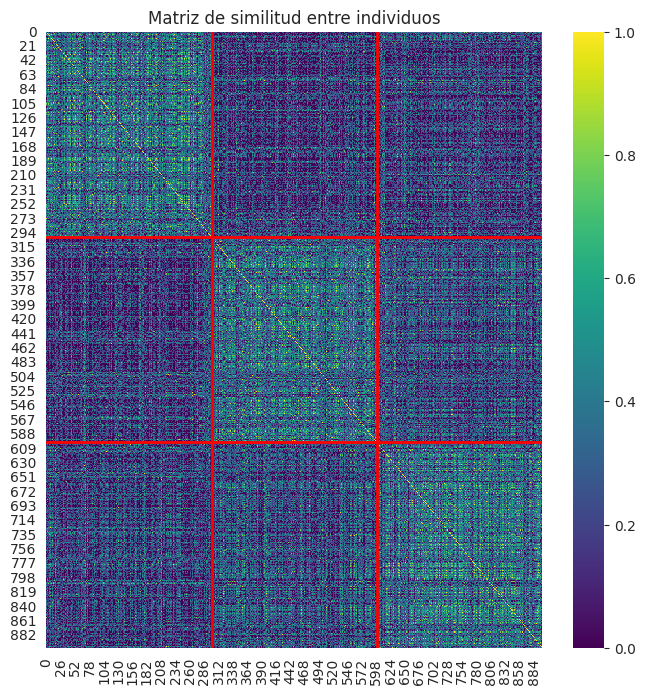

In [ ]:
idx = np.argsort(y)

D_sorted = D_preguntas[idx][:,idx]

S_sorted = 1 - D_sorted

plt.figure(figsize=(8,8))

sns.heatmap(
    S_sorted,
    cmap="viridis"
)

for boundary in [300,600]:
    plt.axhline(boundary,color='red',lw=2)
    plt.axvline(boundary,color='red',lw=2)

plt.title(
    "Matriz de similitud entre individuos"
)

plt.show()

¿Se observa una estructura en bloques?

Hacemos clustering jerárquico y k-medoids

In [ ]:
labels_jerarquico = AgglomerativeClustering(
    n_clusters=3,
    metric='precomputed',
    linkage='average'
).fit_predict(D_preguntas)

ari_preguntas_jerarquico = adjusted_rand_score(
    y,
    labels_jerarquico
)


print(
    "ARI jerárquico en preguntas=",
    ari_preguntas_jerarquico
)


labels_kmedoids = KMedoids(
        n_clusters=3,
        metric='precomputed',
        random_state=0
    ).fit_predict(D_preguntas)

ari_preguntas_kmedoids = adjusted_rand_score(
    y,
    labels_kmedoids
)

print(
    "ARI k-medoids en preguntas=",
    ari_preguntas_kmedoids
)

ARI jerárquico en preguntas= 0.38050181250513493
ARI k-medoids en preguntas= 0.2578930679127334


## Enfoque B

Ahora transformaremos las variables categóricas mediante One-Hot Encoding.

Cada categoría se convertirá en una variable binaria.

Luego calcularemos similitudes utilizando la distancia de Jaccard.

Como teníamos 5 preguntas con 4 respuestas posibles, ahora tenemos 20 atributos binarios

In [ ]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(
    sparse_output=False
)

X_onehot = encoder.fit_transform(df)

print(X_onehot.shape)

(900, 20)


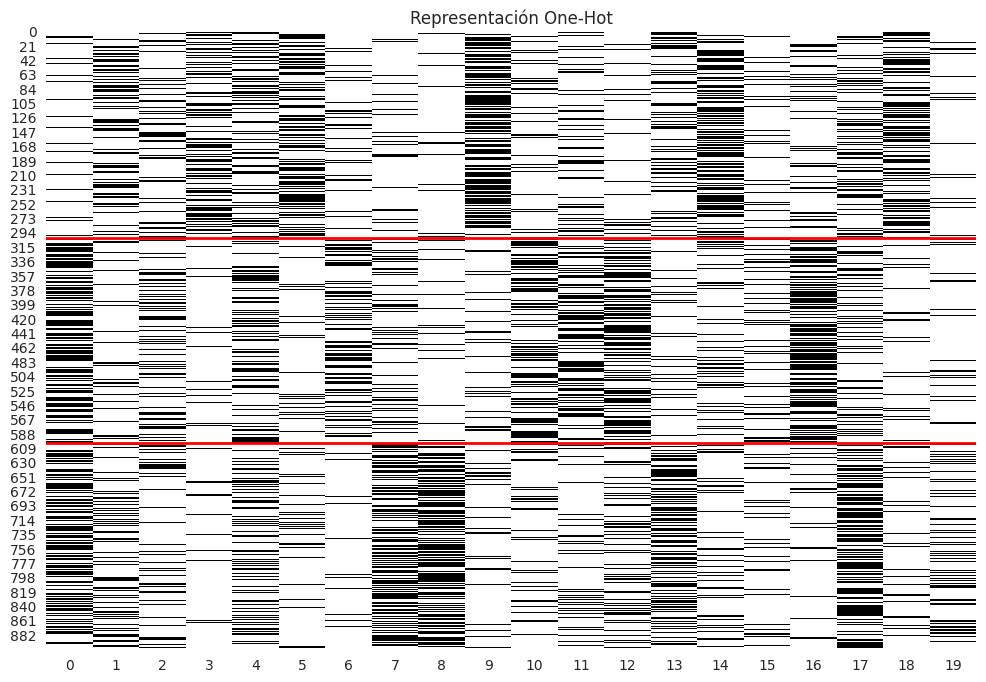

In [ ]:
# Lo visualizamos
idx = np.argsort(y)

plt.figure(figsize=(12,8))

sns.heatmap(
    X_onehot[idx],
    cmap='binary',
    cbar=False
)

for boundary in [300,600]:
    plt.axhline(
        boundary,
        color='red',
        linewidth=2
    )

plt.title(
    "Representación One-Hot"
)

plt.show()

Utilizaremos la distancia de Jaccard (match de 1s en las variables onehot). ¿Podríamos usar otra?

In [ ]:
D_onehot = pairwise_distances(
    X_onehot,
    metric='jaccard'
)

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/pairwise.py:2466: DataConversionWarning: Data was converted to boolean for metric jaccard
  warnings.warn(msg, DataConversionWarning)


Nuevamente clustering jerárquico y k-medoids

In [ ]:
labels_jerarquico = AgglomerativeClustering(
    n_clusters=3,
    metric='precomputed',
    linkage='average'
).fit_predict(D_onehot)

ari_onehot_jerarquico = adjusted_rand_score(
    y,
    labels_jerarquico
)


print(
    "ARI jerárquico en one-hot=",
    ari_onehot_jerarquico
)


labels_kmedoids = KMedoids(
        n_clusters=3,
        metric='precomputed',
        random_state=0,
        init='k-medoids++'
    ).fit_predict(D_onehot)

ari_onehot_kmedoids = adjusted_rand_score(
    y,
    labels_kmedoids
)

print(
    "ARI k-medoids en one-hot=",
   ari_onehot_kmedoids
)

ARI jerárquico en one-hot= 0.2304813157693221
ARI k-medoids en one-hot= 0.23793498147505424


In [ ]:
results = pd.DataFrame({

    "Representación":[
        "Categorías originales",
        "Categorías originales",
        "One-Hot Encoding",
        "One-Hot Encoding"
    ],

    "Distancia":[
        "Coincidencia",
        "Coincidencia",
        "Jaccard",
        "Jaccard"
    ],
    "Algoritmo":[
        "Jerárquico",
        "k-Medoids",
        "Jerárquico",
        "k-Medoids"
    ],
    "ARI":[
        ari_preguntas_jerarquico,
        ari_preguntas_kmedoids,
        ari_onehot_jerarquico,
        ari_onehot_kmedoids
    ],

})

results

,Representación,Distancia,Algoritmo,ARI
0,Categorías originales,Coincidencia,Jerárquico,0.380502
1,Categorías originales,Coincidencia,k-Medoids,0.257893
2,One-Hot Encoding,Jaccard,Jerárquico,0.230481
3,One-Hot Encoding,Jaccard,k-Medoids,0.237935


## Discusión

1. ¿Las dos representaciones producen resultados similares?

2. ¿Cuál de las dos aproximaciones obtuvo mejor ARI?

3. ¿Qué ventajas tiene trabajar directamente sobre las categorías originales? (¿dimensionalidad? ¿Interpretabilidad?)

4. ¿Qué ventajas tiene el One-Hot Encoding? (¿Versatilidad? ¿Posibilidad de usar otros algoritmos de machine learning, como reducción de dimensionalidad?)

5. ¿Crees que estas dos representaciones seguirían comportándose de manera similar si existieran cientos de categorías posibles?

6. ¿Qué aprendemos sobre el papel de la representación de los datos en un problema de clustering?

# Datos mixtos

Muchas bases de datos contienen simultáneamente:

- Variables continuas
- Variables ordinales
- Variables binarias
- Variables categóricas

La distancia de Gower fue diseñada específicamente para este escenario.

In [ ]:
# Instalamos
!pip install gower

Creamos un dataset que consiste a dos encuestas realizadas en lugares diferentes, donde en un caso las personas encuestadas tienden a tener mayor edad, ingresos y nivel educativo

In [ ]:
n = 300 # observaciones de cada dataset

df1 = pd.DataFrame({
    "edad":
        np.random.normal(25,3,n),

    "ingresos":
        np.random.normal(30000,2000,n),

    "educacion":
        np.random.choice(
            [1,2],
            n
        ),

    "sexo":
        np.random.choice(
            [0,1],
            n
        ),

    "region":
        np.random.choice(
            ["Córdoba","Santa Fe"],
            n
        )
})

df2 = pd.DataFrame({
    "edad":
        np.random.normal(35,3,n),

    "ingresos":
        np.random.normal(40000,3000,n),

    "educacion":
        np.random.choice(
            [1,2,3,4],
            n
        ),

    "sexo":
        np.random.choice(
            [0,1],
            n
        ),

    "region":
        np.random.choice(
            ["Caba","Córdoba"],
            n
        )
})


# Creamos un dataset final con ambos datasets concatenados
df = pd.concat([
    df1,
    df2
])

y = np.repeat(
    [0,1],
    n
)

In [ ]:
print('Algunas observaciones del dataset 1')
print(df1.head())
print('')
print('')
print('Algunas observaciones del dataset 2')
print(df2.head())

Algunas observaciones del dataset 1
        edad      ingresos  educacion  sexo    region
0  29.352855  30300.093152          2     1   Córdoba
1  23.302656  27065.501335          2     0  Santa Fe
2  29.633603  32792.124391          2     0   Córdoba
3  23.758713  32351.704593          2     1  Santa Fe
4  23.487604  27727.670291          1     0  Santa Fe


Algunas observaciones del dataset 2
        edad      ingresos  educacion  sexo   region
0  37.036368  44989.690701          4     0     Caba
1  38.460854  42777.598588          1     1  Córdoba
2  33.335802  41377.347839          1     1     Caba
3  34.629198  38762.963655          4     0  Córdoba
4  34.591707  36130.805954          3     1     Caba


In [ ]:
import gower

D = gower.gower_matrix(df)

In [ ]:
labels = AgglomerativeClustering(
    n_clusters=2,
    metric='precomputed',
    linkage='average'
).fit_predict(D)

print(
    "ARI jerárquico:",
    adjusted_rand_score(
        y,
        labels
    )
)

labels = KMedoids(
        n_clusters=2,
        metric='precomputed',
        random_state=0,
        init='k-medoids++'
    ).fit_predict(D)

print(
    "ARI k-medoids:",
    adjusted_rand_score(
        y,
        labels
    )
)

ARI jerárquico: 0.23916019136158337
ARI k-medoids: 0.2388299572153864


# Lo aprendido hasta ahora

1. No existe una única distancia adecuada para todos los tipos de datos.

2. La naturaleza de las variables debe guiar la elección de la distancia.

3. En muchos casos la distancia tiene un impacto comparable o incluso mayor que el algoritmo de clustering.

4. Sobre validación: en esta demostración usamos princpialmente el índice ARI. Sin embargo, este índice no es una verdad revelada, y una validación con otros índices podría dar otros resultados. S**IEMPRE** usar diferentes métodos de validación y tratar de buscar un consenso, analizando qué mide cada índice de validación.




# Clustering y Alta dimensionalidad

En muchas aplicaciones reales los datos poseen un gran número de variables.

Ejemplos:

- Expresión génica
- Datos de clientes
- Imágenes
- Texto representado mediante embeddings
- Actividad neuronal

En estos escenarios aparece un fenómeno conocido como:

## Maldición de la dimensionalidad

A medida que aumenta el número de dimensiones:

- las distancias entre observaciones se vuelven menos informativas
- las muestras tienden a parecerse entre sí
- el clustering se vuelve más difícil

En esta sección estudiaremos cómo la reducción de dimensionalidad puede mejorar el desempeño de los algoritmos de clustering.

Volvamos al dataseet digits de fotos de números escritos

In [ ]:
from sklearn.datasets import fetch_openml, load_digits
from sklearn.preprocessing import scale
from umap import UMAP
import matplotlib as mpl

## Función auxiliar

In [ ]:
def mosaic(imgs_array, n_columns=6):
    dims = imgs_array.shape[1:3]

    width = int(n_columns * dims[1])
    n_rows = np.ceil(imgs_array.shape[0] / n_columns)
    height = int(n_rows * dims[0])

    if imgs_array.ndim == 3:
        mosaic = np.zeros((height, width))
    elif imgs_array.ndim == 4:
        mosaic = np.zeros((height, width, imgs_array.shape[3]))

    for k, img in enumerate(imgs_array):
        i = k // n_columns
        j = k % n_columns
        mosaic[i * dims[1]:(i + 1) * dims[1], j * dims[0]
                            :(j + 1) * dims[0]] = img
    return mosaic

## Dataset digits

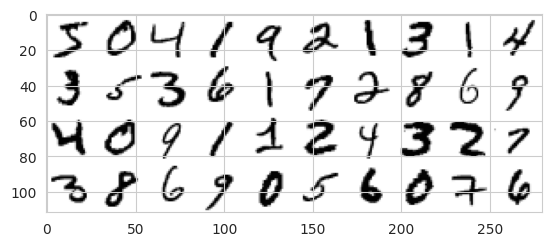

In [ ]:
X, y = fetch_openml('mnist_784', version=1, return_X_y=True)
y = list(map(int,y))
Xim = np.array(X).reshape(len(X),28,28)
X = scale(X)
plt.imshow(mosaic(Xim[:40],10),cmap=plt.cm.gray_r);

Reducimos la dimensionalidad con UMAP. Para esta demostración no nos vamos a enfocar en optimizar su performance, sino que usaremos parámetros por defecto.

In [ ]:
# Reducimos la dimensionalidad con UMAP

um = UMAP(n_neighbors=25)
Xred = um.fit_transform(X)


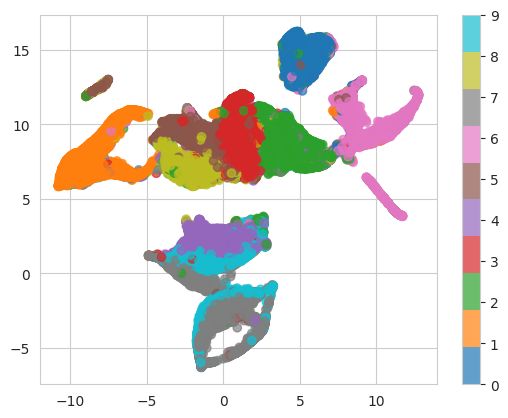

In [ ]:
# Visualizamos los datos en espacio UMAP

cmap = mpl.colors.LinearSegmentedColormap.from_list(
    'Custom cmap', plt.cm.tab10(np.arange(10)), 10)

plt.scatter(Xred[:,0],Xred[:,1],c=y,cmap=cmap,alpha=0.7)
plt.colorbar(ticks=range(10));

Hacemos k-means en el dataset original

In [ ]:
labels_orig = run_kmeans(
    X,
    k=10
)

ari_orig = adjusted_rand_score(
    y,
    labels_orig
)


print("ARI en espacio original=", ari_orig)

ARI en espacio original= 0.32185426676371315


Hacemos k-means en el espacio UMAP

In [ ]:
labels_umap = run_kmeans(
    Xred,
    k=10
)

ari_umap = adjusted_rand_score(
    y,
    labels_umap
)


print("ARI en espacio de dimensionalidad reducida=", ari_umap)


ARI en espacio de dimensionalidad reducida= 0.5922511294486548


### Discusión

La reducción de dimensionalidad **no es mágica**. Puede ayudar al agrupamiento de los datos, o no. Entre otras cosas, dependerá de los atributos originales de alta dimensionalidad elegidos para representar los datos, y del algoritmo de reducción de dimensionalidad aplicado.

Por decir algo:


1.   PCA busca componentes que maximicen varianza. Esto no garantiza una representación que mejore la separación entre clusters. Sin embargo, el solo hecho de proyectar los datos en un espacio de menor dimensionalidad puede mejorar con la maldición de la dimensionalidad.
2.   UMAP si está orientado a encontrar una representación en la que los puntos cercanos se mantengan cercanos, y los que estén un poco más distantes estén mucho más distantes en el espacio de dimensionalidad reducida. Esto en principio puede apiñar puntos en clusters separados entre sí pero, como ya vimos, puede "alucinar" clusters o granulosidades.  

